In [2]:
import numpy as np
from scipy import stats as stats
import matplotlib.pyplot as plt
def generate_data(n,p):
    epsilon = 0.01
    size = (n,p)
    y_size = (n,1)
    x = np.random.normal(size=size)
    y = np.random.randint(0,2,size=y_size)
    return x,y

X, y = generate_data(20,2)

def sigmoid(x):
    return 1 / (1 +np.exp(-x))

def grad_sigmoid(x):
    return sigmoid(x)*(1-sigmoid(x))

def y_hat(X,w):
    return sigmoid(X@w)
def grad_y_hat(X,w):
    z = X@w
    return X.T


def BCE(y,y_hat):
    return np.mean(-y*np.log(y_hat)-(1-y)*np.log(1-y_hat))

def grad_BCE(y,X,w):
    prediction = y_hat(X,w)
    return -X.T@(y - prediction)

weights = np.random.normal(size=(X.shape[1],1))
num_epochs=1000
def training(X,y,num_epochs=100,eta=0.01):
    size=X.shape[1]
    weights = np.random.normal(size=(size,1))
    weights_storage = []
    loss_storage = []
    for epoch in range(num_epochs):
        prediction = y_hat(X,weights)
        weights_storage.append(weights)
        loss = BCE(y,prediction)
        loss_storage.append(loss)
        weights = weights - eta*grad_BCE(y,X,weights)
        if epoch % 100 == 0:
            print(f"Epoch number {epoch}, weights {weights}")
    return weights_storage, loss_storage
    
storage, loss_storage = training(X,y,num_epochs=num_epochs)

Epoch number 0, weights [[-1.21275294]
 [ 1.11940079]]
Epoch number 100, weights [[ 0.50860718]
 [-0.48675395]]
Epoch number 200, weights [[ 0.60914789]
 [-0.58009314]]
Epoch number 300, weights [[ 0.61779788]
 [-0.58847272]]
Epoch number 400, weights [[ 0.61859083]
 [-0.5892481 ]]
Epoch number 500, weights [[ 0.6186641 ]
 [-0.58931986]]
Epoch number 600, weights [[ 0.61867088]
 [-0.5893265 ]]
Epoch number 700, weights [[ 0.61867151]
 [-0.58932712]]
Epoch number 800, weights [[ 0.61867157]
 [-0.58932718]]
Epoch number 900, weights [[ 0.61867157]
 [-0.58932718]]


Text(0.5, 1.0, 'Loss function of 1000 iteration')

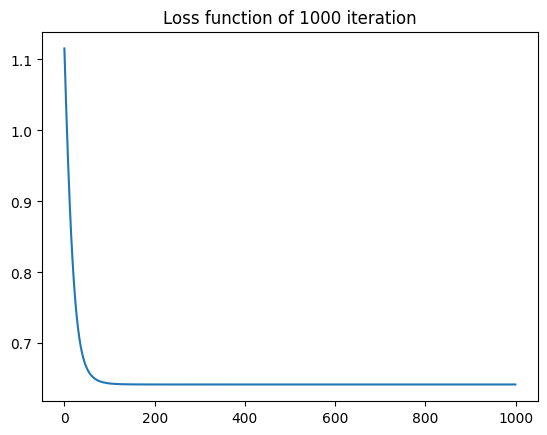

In [3]:
plt.plot(loss_storage)
plt.title(f"Loss function of {num_epochs} iteration")

In [4]:
storage = np.array(storage)

In [5]:
storage = storage[:,:,-1]
storage.shape

(1000, 2)

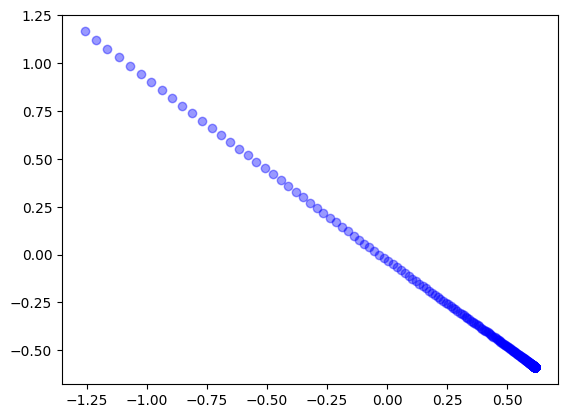

In [6]:
for x,y in storage:
    plt.scatter(x,y,color='blue',alpha=0.4)

# Standard Linear Regression

In [9]:
def generate_data(n,p):
    epsilon = 0.01
    size = (n,p)
    y_size = (n,1)
    x = np.random.normal(size=size)
    y = np.random.normal(0,2,size=y_size)
    return x,y

n = 20
p = 2
X_, y = generate_data(n,p)


def prediction(X,w):
    size = X.shape[1]
    return X@w
def MSE(y,y_hat):
    return np.mean((y-y_hat)**2) / 2
def grad_MSE(y,X,w):
    y_hat = prediction(X,w)
    return X.T@(y_hat-y)
print(grad_MSE(y,X,weights))

def training_L(X,y,num_epochs=100,eta=0.01):
    size=X.shape[1]
    weights = np.random.normal(size=(size,1))
    storage = []
    loss_storage = []
    for epoch in range(num_epochs):
        storage.append(weights)
        loss = MSE(y,prediction(X_,weights))
        loss_storage.append(loss)
        if epoch % 100 == 0:
            print(f"Epoch number {epoch}, weights {weights}")
        weights = weights - eta*grad_MSE(y,X_,weights)
    return storage
    
storage = training_L(X_,y)
storage=np.array(storage)
storage = storage[:,:,-1]

[[-26.44588007]
 [-23.97748268]]
Epoch number 0, weights [[-0.12186272]
 [-1.30025045]]


Text(0.5, 1.0, 'Loss function of 1000 iteration')

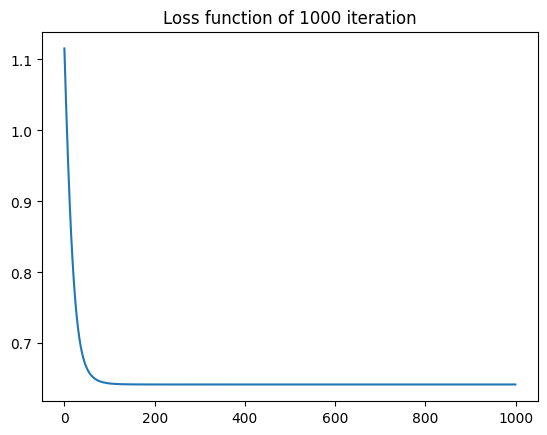

In [10]:
plt.plot(loss_storage)
plt.title(f"Loss function of {num_epochs} iteration")